# 🔵 K-Means — Agrupamiento No Supervisado — Dataset Iris
**Diplomado en Redes Neuronales y Deep Learning**

Este notebook cubre:
1. ¿Qué es K-Means y por qué es diferente?
2. Carga y exploración del dataset (150 muestras)
3. Preprocesamiento: normalización única + variables clon
4. K-Means con las 3 clases completas
5. Comparativa por pares: Setosa vs Versicolor, Setosa vs Virginica, Versicolor vs Virginica
6. ¿Petal o Sepal? Justificación de la elección de features
7. Evaluación: ¿qué tan bien encontró los grupos reales?
8. Método del codo para elegir el K óptimo

---
## 🧠 1. ¿Qué es K-Means y por qué es diferente?

### Aprendizaje Supervisado vs No Supervisado

| | Supervisado (Árbol, SVM) | No Supervisado (K-Means) |
|---|---|---|
| **¿Necesita etiquetas?** | ✅ Sí (sabe que es setosa/versicolor) | ❌ No (solo ve números) |
| **¿Qué aprende?** | A clasificar según ejemplos conocidos | A encontrar grupos por similitud |
| **¿Para qué sirve?** | Predecir la clase de datos nuevos | Descubrir patrones ocultos |

### ¿Qué hace K-Means exactamente?

K-Means intenta dividir los datos en **"K" grupos (clusters)** donde los puntos dentro de cada grupo
sean lo más similares posible entre sí y lo más diferentes posible de los otros grupos.

El algoritmo funciona así:
1. Coloca **K centroides** (centros de grupo) aleatoriamente
2. Asigna cada punto al centroide más cercano
3. Mueve cada centroide al promedio de sus puntos
4. Repite hasta que los centroides no se muevan

### ¿Por qué comparar por pares?

Iris tiene 3 especies. Setosa es fácil de separar, pero Versicolor y Virginica se parecen mucho.
Al comparar por pares (Setosa-Versicolor, Setosa-Virginica, Versicolor-Virginica) podemos ver:
- ¿En cuál par K-Means tiene más fácil identificar los grupos?
- ¿Cuál par confunde más al algoritmo?
- Esto nos ayuda a entender la 'dificultad' de cada separación

En la vida real, cuando **no tenemos etiquetas**, K-Means es útil para:
- Segmentación de clientes
- Detección de anomalías
- Compresión de imágenes
- Descubrimiento de temas en textos

---
## 📦 2. Importaciones y carga del dataset

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.environ["OMP_NUM_THREADS"] = "1"

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, confusion_matrix

# Cargamos el dataset completo (150 muestras)
iris = load_iris()
X = iris.data           # Las 4 características de las 150 flores
y = iris.target         # Las etiquetas reales (solo para evaluar al final)
feature_names = iris.feature_names
class_names   = iris.target_names   # ['setosa', 'versicolor', 'virginica']

# DataFrame para exploración
df = pd.DataFrame(X, columns=feature_names)
df['especie'] = pd.Categorical.from_codes(iris.target, class_names)

print(f"Total de muestras: {len(df)}")
print(f"  - Setosa    (clase 0): {sum(y==0)} muestras (filas 0-49)")
print(f"  - Versicolor (clase 1): {sum(y==1)} muestras (filas 50-99)")
print(f"  - Virginica  (clase 2): {sum(y==2)} muestras (filas 100-149)")
print()
display(df.head(8))

Total de muestras: 150
  - Setosa    (clase 0): 50 muestras (filas 0-49)
  - Versicolor (clase 1): 50 muestras (filas 50-99)
  - Virginica  (clase 2): 50 muestras (filas 100-149)



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),especie
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa


---
## 🔧 3. Preprocesamiento: Normalización única + Variables Clon

### ¿Por qué normalizar?
K-Means usa **distancias** para decidir qué puntos van juntos.
Si una feature va de 0 a 10 y otra de 0 a 1000, la segunda dominaría el cálculo.
Con `StandardScaler` todas las features quedan en la misma escala.

### Optimización: normalizar UNA sola vez
En lugar de normalizar los datos una y otra vez para cada comparación,
normalizamos **todo el dataset una sola vez** y luego creamos **copias (clones)** del subconjunto que necesitamos.
Esto es más limpio, más eficiente y evita errores de inconsistencia.

In [32]:
# One-Hot Encoding de la especie (para análisis de correlación)
df_ohe = pd.get_dummies(df, columns=['especie'], dtype=int)
print("DataFrame con One-Hot Encoding:")
display(df_ohe.head(6))

DataFrame con One-Hot Encoding:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),especie_setosa,especie_versicolor,especie_virginica
0,5.1,3.5,1.4,0.2,1,0,0
1,4.9,3.0,1.4,0.2,1,0,0
2,4.7,3.2,1.3,0.2,1,0,0
3,4.6,3.1,1.5,0.2,1,0,0
4,5.0,3.6,1.4,0.2,1,0,0
5,5.4,3.9,1.7,0.4,1,0,0


In [33]:
# --- Normalización única de todo el dataset ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Todas las 150 muestras normalizadas de una vez

print("Dataset original (primeras 3 filas):")
print(X[:3].round(3))
print("\nDataset normalizado (mismas 3 filas):")
print(X_scaled[:3].round(3))
print("\nMedia después de escalar (debe ser ~0):", X_scaled.mean(axis=0).round(4))
print("Std  después de escalar (debe ser ~1):",  X_scaled.std(axis=0).round(4))

# --- Variables Clon: subconjuntos ya normalizados para cada comparación ---
# No renormalizamos, solo tomamos las filas que nos interesan del dataset ya normalizado

# Clase 0 = Setosa     (filas 0-49)
# Clase 1 = Versicolor (filas 50-99)
# Clase 2 = Virginica  (filas 100-149)

X_setosa_ver  = X_scaled[:100]    # Setosa + Versicolor (clon 1)
y_setosa_ver  = y[:100]

X_setosa_vir  = np.vstack([X_scaled[:50], X_scaled[100:]])  # Setosa + Virginica (clon 2)
y_setosa_vir  = np.hstack([y[:50], y[100:]])

X_ver_vir     = X_scaled[50:]     # Versicolor + Virginica (clon 3)
y_ver_vir     = y[50:]

print("\nVariables clon creadas:")
print(f"  X_setosa_ver:  {X_setosa_ver.shape}  → Setosa (0-49) + Versicolor (50-99)")
print(f"  X_setosa_vir:  {X_setosa_vir.shape}  → Setosa (0-49) + Virginica (100-149)")
print(f"  X_ver_vir:     {X_ver_vir.shape}  → Versicolor (50-99) + Virginica (100-149)")

Dataset original (primeras 3 filas):
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]

Dataset normalizado (mismas 3 filas):
[[-0.901  1.019 -1.34  -1.315]
 [-1.143 -0.132 -1.34  -1.315]
 [-1.385  0.328 -1.397 -1.315]]

Media después de escalar (debe ser ~0): [-0. -0. -0. -0.]
Std  después de escalar (debe ser ~1): [1. 1. 1. 1.]

Variables clon creadas:
  X_setosa_ver:  (100, 4)  → Setosa (0-49) + Versicolor (50-99)
  X_setosa_vir:  (100, 4)  → Setosa (0-49) + Virginica (100-149)
  X_ver_vir:     (100, 4)  → Versicolor (50-99) + Virginica (100-149)


---
## 🌸 4. ¿Petal o Sepal? Justificación de la elección de features

Para visualizar K-Means en 2D necesitamos elegir 2 features.
Calculamos la correlación con la especie para saber cuáles discriminan mejor.

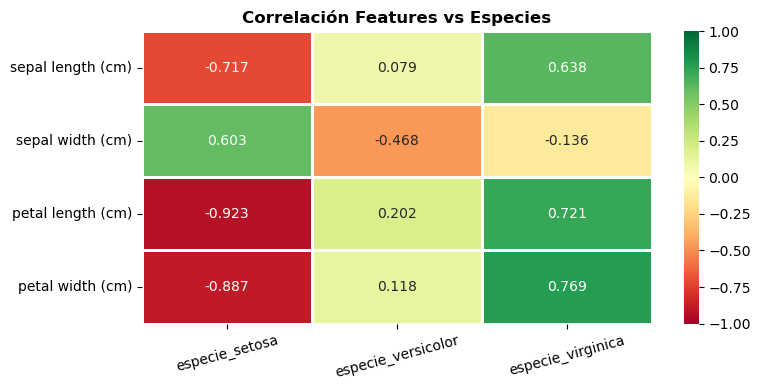

💡 ¿Petal o Sepal?
   petal length y petal width tienen correlaciones MÁS ALTAS con las especies
   → Son las features más discriminativas → las usamos para visualizar

   sepal length y sepal width tienen correlaciones más bajas
   → Aportan menos para distinguir las especies en la visualización 2D

   Por eso usamos petal length (índice 2) y petal width (índice 3)


In [34]:
# Correlación features vs especies
corr = df_ohe.corr().round(3)
especies_ohe = ['especie_setosa', 'especie_versicolor', 'especie_virginica']
corr_feat_esp = corr.loc[feature_names, especies_ohe]

plt.figure(figsize=(8, 4))
sns.heatmap(corr_feat_esp, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, linewidths=1, vmin=-1, vmax=1)
plt.title('Correlación Features vs Especies', fontsize=12, fontweight='bold')
plt.xticks(rotation=15)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("💡 ¿Petal o Sepal?")
print("   petal length y petal width tienen correlaciones MÁS ALTAS con las especies")
print("   → Son las features más discriminativas → las usamos para visualizar")
print()
print("   sepal length y sepal width tienen correlaciones más bajas")
print("   → Aportan menos para distinguir las especies en la visualización 2D")
print()
print("   Por eso usamos petal length (índice 2) y petal width (índice 3)")

In [35]:
# Índices de las features de pétalo para visualización 2D
FEAT_VIS = [2, 3]  # petal length, petal width
feat_labels = [feature_names[2], feature_names[3]]

print(f"Features para visualización: {feat_labels}")

Features para visualización: ['petal length (cm)', 'petal width (cm)']


---
## 🔵 5. K-Means con las 3 clases completas (150 muestras)

Le pedimos a K-Means que encuentre **3 grupos** sin decirle cuáles son.
Usamos las 4 features para el modelo, pero visualizamos en 2D (petal length vs petal width).

In [36]:
# --- K-Means con K=3 sobre todas las 150 muestras normalizadas ---
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_3 = kmeans_3.fit_predict(X_scaled)

print("K-Means con K=3 (150 muestras, 4 features):")
print(f"  Inercia (suma de distancias al centroide): {kmeans_3.inertia_:.2f}")
print(f"  Centroides encontrados (en espacio normalizado):")
for i, c in enumerate(kmeans_3.cluster_centers_):
    print(f"    Cluster {i}: {c.round(3)}")

# Cuántas flores asignó a cada cluster
vals, cnts = np.unique(clusters_3, return_counts=True)
print(f"\n  Distribución de clusters:")
for v, c in zip(vals, cnts):
    print(f"    Cluster {v}: {c} flores")

K-Means con K=3 (150 muestras, 4 features):
  Inercia (suma de distancias al centroide): 139.82
  Centroides encontrados (en espacio normalizado):
    Cluster 0: [-0.05  -0.883  0.348  0.282]
    Cluster 1: [-1.015  0.853 -1.305 -1.255]
    Cluster 2: [1.136 0.088 0.996 1.018]

  Distribución de clusters:
    Cluster 0: 53 flores
    Cluster 1: 50 flores
    Cluster 2: 47 flores


c:\Users\Darck\anaconda3\envs\diplomado-redes\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


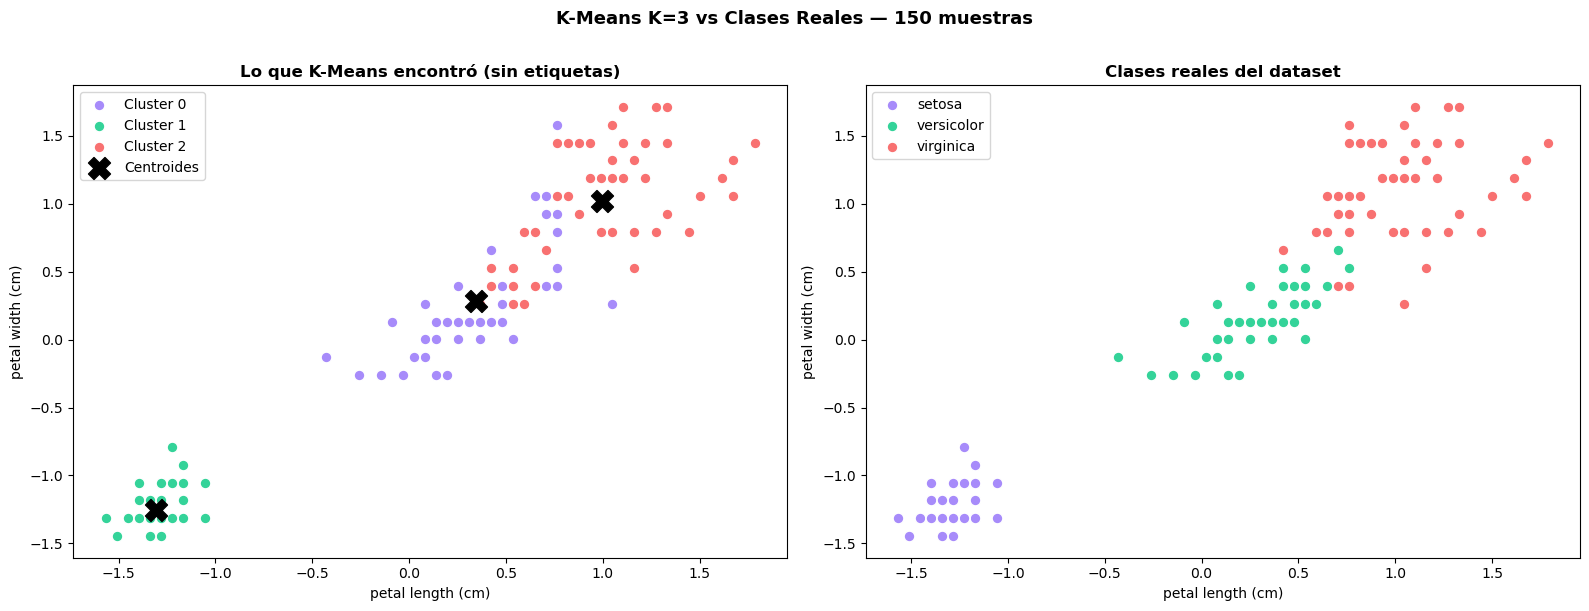


💡 Adjusted Rand Index (qué tan parecidos son los clusters a las clases reales):
   ARI = 0.6201  (0=aleatorio, 1=perfecto)
   Interpretación: Bueno


In [37]:
# --- Visualización 2D: clusters K-Means vs clases reales ---
colores_k = ['#a78bfa', '#34d399', '#f87171']
colores_r = ['#6d28d9', '#065f46', '#991b1b']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel izquierdo: lo que encontró K-Means (sin saber las etiquetas reales)
for i in range(3):
    mask = clusters_3 == i
    axes[0].scatter(X_scaled[mask, 2], X_scaled[mask, 3],
                    c=colores_k[i], label=f'Cluster {i}', s=60, edgecolors='white')

# Centroides en el espacio 2D (petal length vs petal width)
axes[0].scatter(kmeans_3.cluster_centers_[:, 2], kmeans_3.cluster_centers_[:, 3],
                c='black', marker='X', s=250, zorder=5, label='Centroides')
axes[0].set_title('Lo que K-Means encontró (sin etiquetas)', fontsize=12, fontweight='bold')
axes[0].set_xlabel(feat_labels[0])
axes[0].set_ylabel(feat_labels[1])
axes[0].legend()

# Panel derecho: las clases reales (para comparar)
for i, nombre in enumerate(class_names):
    mask = y == i
    axes[1].scatter(X_scaled[mask, 2], X_scaled[mask, 3],
                    c=colores_k[i], label=nombre, s=60, edgecolors='white')
axes[1].set_title('Clases reales del dataset', fontsize=12, fontweight='bold')
axes[1].set_xlabel(feat_labels[0])
axes[1].set_ylabel(feat_labels[1])
axes[1].legend()

plt.suptitle('K-Means K=3 vs Clases Reales — 150 muestras', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Qué tan bien coincidieron los clusters con las clases reales
ari_3 = adjusted_rand_score(y, clusters_3)
print(f"\n💡 Adjusted Rand Index (qué tan parecidos son los clusters a las clases reales):")
print(f"   ARI = {ari_3:.4f}  (0=aleatorio, 1=perfecto)")
print(f"   Interpretación: {'Excelente' if ari_3 > 0.8 else 'Bueno' if ari_3 > 0.5 else 'Regular'}")

---
## 🔄 6. Comparativa por pares

Ahora comparamos K-Means aplicado solo a 2 clases a la vez.
Usamos las **variables clon** que creamos antes (ya normalizadas).

El objetivo es ver:
- ¿Qué par se separa mejor?
- ¿Dónde confunde más K-Means?
- ¿Cómo cambia la forma de los clusters?

Usamos `K=2` porque en cada comparación solo hay **2 clases**.

c:\Users\Darck\anaconda3\envs\diplomado-redes\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Darck\anaconda3\envs\diplomado-redes\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Darck\anaconda3\envs\diplomado-redes\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


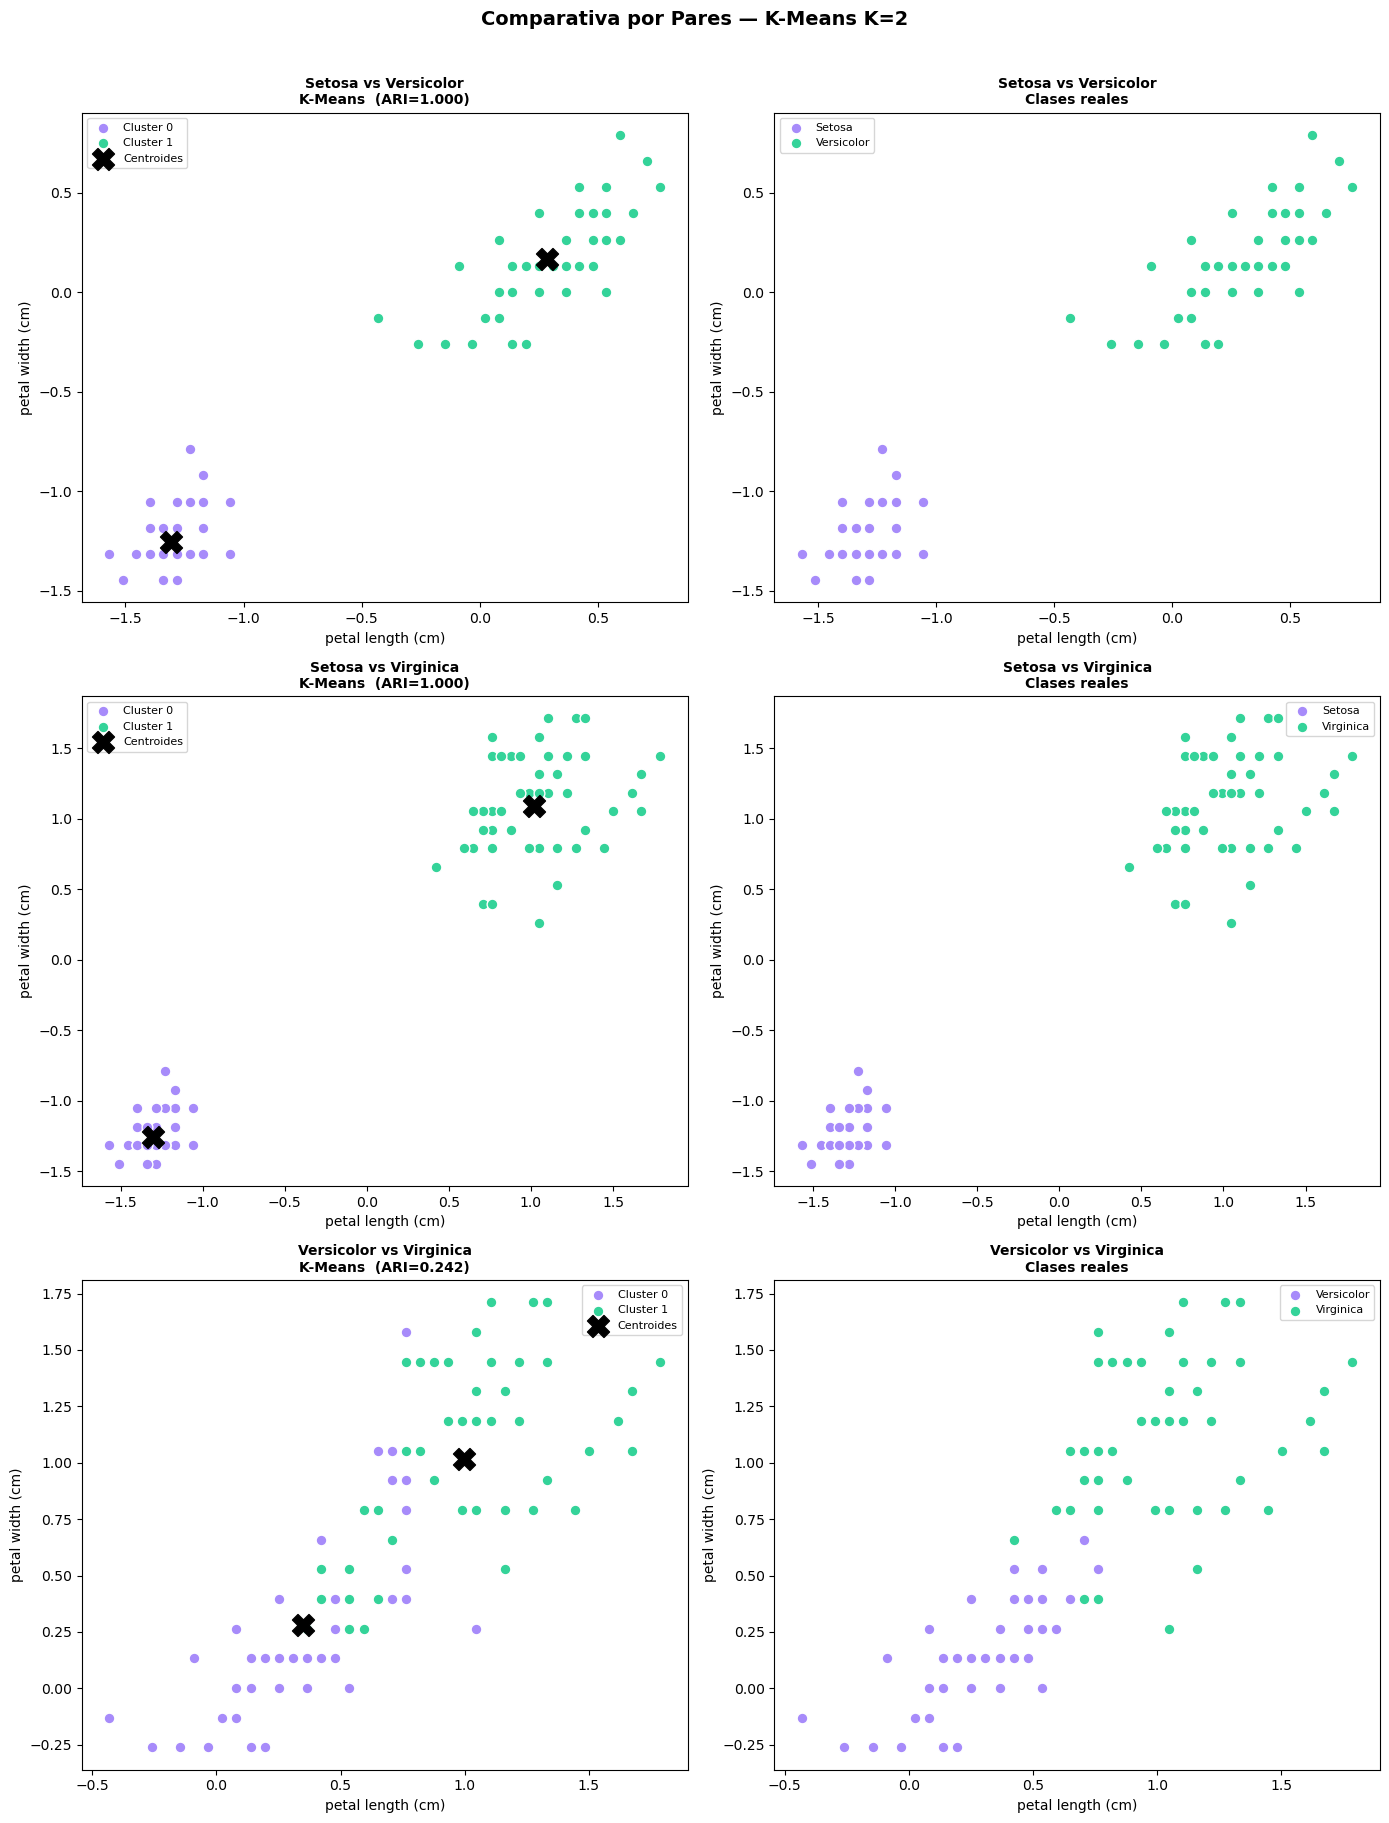


📊 Resumen de comparativas por par:
  Par                                 ARI    Inercia Dificultad
  -----------------------------------------------------------------
  Setosa vs Versicolor             1.0000      99.22  ✅ Fácil
  Setosa vs Virginica              1.0000     114.99  ✅ Fácil
  Versicolor vs Virginica          0.2424      92.15  ❌ Difícil


In [38]:
def plot_kmeans_par(X_par, y_par, titulo, nombres_clases, ax_kmeans, ax_real):
    """Visualiza K-Means vs clases reales para un par de clases."""
    colores = ['#a78bfa', '#34d399']

    # K-Means con K=2
    km = KMeans(n_clusters=2, random_state=42, n_init=10)
    clusters = km.fit_predict(X_par)
    ari = adjusted_rand_score(y_par, clusters)

    # Panel K-Means
    for i in range(2):
        mask = clusters == i
        ax_kmeans.scatter(X_par[mask, 2], X_par[mask, 3],
                          c=colores[i], label=f'Cluster {i}', s=60, edgecolors='white')
    ax_kmeans.scatter(km.cluster_centers_[:, 2], km.cluster_centers_[:, 3],
                      c='black', marker='X', s=250, zorder=5, label='Centroides')
    ax_kmeans.set_title(f'{titulo}\nK-Means  (ARI={ari:.3f})', fontsize=10, fontweight='bold')
    ax_kmeans.set_xlabel(feat_labels[0])
    ax_kmeans.set_ylabel(feat_labels[1])
    ax_kmeans.legend(fontsize=8)

    # Panel clases reales
    clases_unicas = np.unique(y_par)
    for i, (clase, nombre) in enumerate(zip(clases_unicas, nombres_clases)):
        mask = y_par == clase
        ax_real.scatter(X_par[mask, 2], X_par[mask, 3],
                        c=colores[i], label=nombre, s=60, edgecolors='white')
    ax_real.set_title(f'{titulo}\nClases reales', fontsize=10, fontweight='bold')
    ax_real.set_xlabel(feat_labels[0])
    ax_real.set_ylabel(feat_labels[1])
    ax_real.legend(fontsize=8)

    return ari, km.inertia_


fig, axes = plt.subplots(3, 2, figsize=(14, 18))

ari_sv, iner_sv = plot_kmeans_par(
    X_setosa_ver, y_setosa_ver,
    'Setosa vs Versicolor',
    ['Setosa', 'Versicolor'],
    axes[0, 0], axes[0, 1]
)

ari_svi, iner_svi = plot_kmeans_par(
    X_setosa_vir, y_setosa_vir,
    'Setosa vs Virginica',
    ['Setosa', 'Virginica'],
    axes[1, 0], axes[1, 1]
)

ari_vv, iner_vv = plot_kmeans_par(
    X_ver_vir, y_ver_vir,
    'Versicolor vs Virginica',
    ['Versicolor', 'Virginica'],
    axes[2, 0], axes[2, 1]
)

plt.suptitle('Comparativa por Pares — K-Means K=2', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n📊 Resumen de comparativas por par:")
print(f"  {'Par':<30} {'ARI':>8} {'Inercia':>10} {'Dificultad'}")
print("  " + "-"*65)
print(f"  {'Setosa vs Versicolor':<30} {ari_sv:>8.4f} {iner_sv:>10.2f}  {'✅ Fácil' if ari_sv > 0.8 else '⚠️ Moderado' if ari_sv > 0.5 else '❌ Difícil'}")
print(f"  {'Setosa vs Virginica':<30} {ari_svi:>8.4f} {iner_svi:>10.2f}  {'✅ Fácil' if ari_svi > 0.8 else '⚠️ Moderado' if ari_svi > 0.5 else '❌ Difícil'}")
print(f"  {'Versicolor vs Virginica':<30} {ari_vv:>8.4f} {iner_vv:>10.2f}  {'✅ Fácil' if ari_vv > 0.8 else '⚠️ Moderado' if ari_vv > 0.5 else '❌ Difícil'}")

---
## 📐 7. Evaluación: ¿qué tan bien encontró los grupos reales?

En K-Means real no tendríamos etiquetas, pero con Iris **sí las tenemos** y podemos usarlas
para evaluar qué tan bien el algoritmo descubrió los grupos naturales.

### Métricas de evaluación:
- **ARI (Adjusted Rand Index)**: compara los clusters con las clases reales. 1=perfecto, 0=aleatorio
- **Inercia**: suma de distancias de cada punto a su centroide. Menor = clusters más compactos

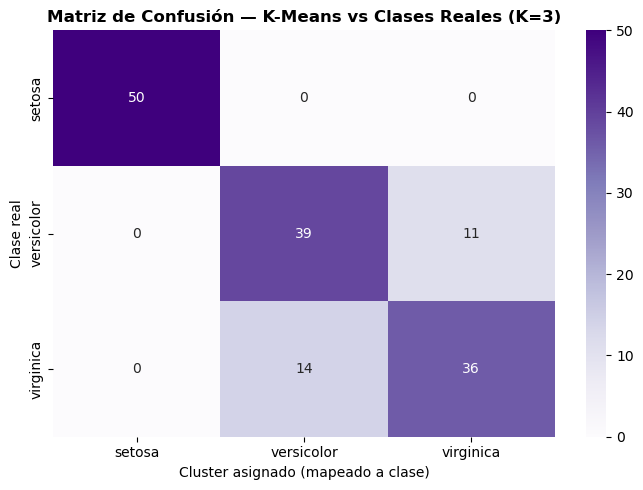


Aciertos totales de K-Means: 125/150 = 83.3%
ARI: 0.6201

💡 Interpretación:
   La diagonal muestra cuántas flores cada clase fue asignada al cluster correcto.
   Setosa suele quedar perfecta (muy separada de las demás).
   Versicolor y Virginica a veces se confunden porque se superponen.


In [39]:
# Matriz de confusión entre clusters y clases reales (para las 3 clases)
# Los clusters no tienen nombres, solo números, así que buscamos la mejor asignación
from scipy.optimize import linear_sum_assignment

def mejor_asignacion_clusters(y_real, clusters, n_clases):
    """Encuentra la mejor asignación entre clusters y clases reales."""
    cm = confusion_matrix(y_real, clusters)
    # Maximizamos la diagonal (que el cluster X corresponda mejor a la clase Y)
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    return np.array([mapping[c] for c in clusters])

clusters_mapeados = mejor_asignacion_clusters(y, clusters_3, 3)

cm = confusion_matrix(y, clusters_mapeados)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Cluster asignado (mapeado a clase)')
plt.ylabel('Clase real')
plt.title('Matriz de Confusión — K-Means vs Clases Reales (K=3)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

accuracy = np.trace(cm) / cm.sum()
print(f"\nAciertos totales de K-Means: {np.trace(cm)}/150 = {accuracy*100:.1f}%")
print(f"ARI: {adjusted_rand_score(y, clusters_3):.4f}")
print()
print("💡 Interpretación:")
print("   La diagonal muestra cuántas flores cada clase fue asignada al cluster correcto.")
print("   Setosa suele quedar perfecta (muy separada de las demás).")
print("   Versicolor y Virginica a veces se confunden porque se superponen.")

---
## 📈 8. Método del Codo: ¿cuántos clusters usar?

En la vida real **no sabemos cuántos grupos hay**. El método del codo nos ayuda a decidir el K óptimo.

Graficamos la inercia para distintos valores de K. Cuando la curva 'se dobla como un codo',
ese es el K que mejor balancea complejidad y calidad de clusters.

c:\Users\Darck\anaconda3\envs\diplomado-redes\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Darck\anaconda3\envs\diplomado-redes\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Darck\anaconda3\envs\diplomado-redes\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Darck\anaconda3\envs\diplomado-redes\Lib\site-packages\sklearn\c

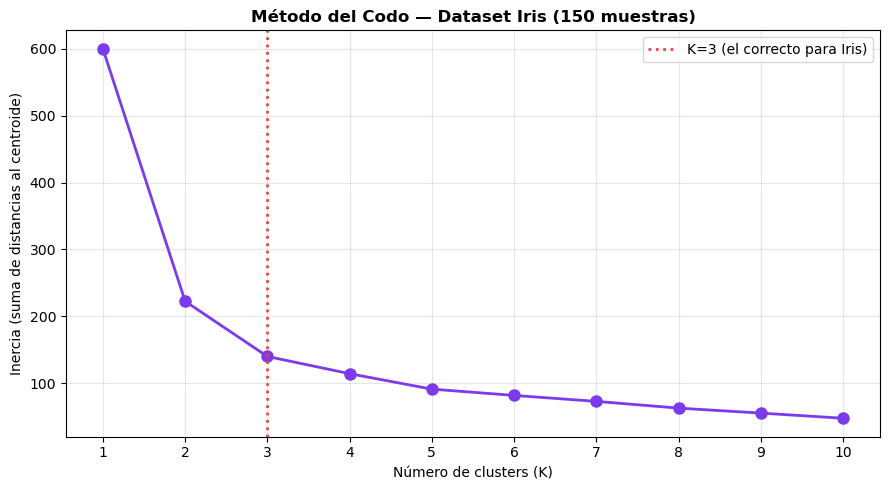

💡 El 'codo' se forma en K= 4 → confirma que hay 3 grupos naturales en el dataset.
   A partir de K= 4, agregar más clusters reduce poco la inercia.
   En datos reales sin etiquetas, usaríamos esta gráfica para elegir K.


In [42]:
inercias = []
rango_k = range(1, 11)

for k in rango_k:
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_temp.fit(X_scaled)
    inercias.append(km_temp.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(rango_k, inercias, 'o-', color='#7c3aed', linewidth=2, markersize=8)
plt.axvline(x=3, color='#ef4444', linestyle=':', linewidth=2, label='K=3 (el correcto para Iris)')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia (suma de distancias al centroide)')
plt.title('Método del Codo — Dataset Iris (150 muestras)', fontsize=12, fontweight='bold')
plt.legend()
plt.xticks(rango_k)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("💡 El 'codo' se forma en K= " + str(rango_k[3]) + " → confirma que hay 3 grupos naturales en el dataset.")
print("   A partir de K= " + str(rango_k[3]) + ", agregar más clusters reduce poco la inercia.")
print("   En datos reales sin etiquetas, usaríamos esta gráfica para elegir K.")

---
## 📝 9. Resumen y conclusiones

### ¿Qué aprendimos?

**K-Means vs Árbol vs SVM:**

| | Árbol de Decisión | SVM | K-Means |
|---|---|---|---|
| **Tipo** | Supervisado | Supervisado | No Supervisado |
| **Necesita etiquetas** | ✅ Sí | ✅ Sí | ❌ No |
| **Normalización** | ❌ No | ✅ Sí | ✅ Sí |
| **Parámetro clave** | max_depth | C, kernel | K (n_clusters) |
| **Resultado** | Clase predicha | Clase predicha | Número de cluster |

**Por pares:**
- Setosa vs cualquiera → fácil (Setosa es muy diferente)
- Versicolor vs Virginica → difícil (se parecen mucho en features de sépalo)

**¿Por qué Petal y no Sepal?**
- petal length y petal width tienen mayor correlación con las especies
- En sepal, las 3 especies se superponen mucho
- En petal, Setosa queda completamente separada

**Optimización:**
- Normalizar UNA sola vez y usar variables clon evita cálculos redundantes
- Todos los subconjuntos comparten la misma escala → comparaciones justas

**Proyecto final (adelanto):**
Para pingüinos aplicariamos el flujo:
K-Means → SVM → Árbol → etc..  , comparando qué modelo clasifica mejor las especies.